In [55]:
%matplotlib inline
import random
import torch
from torch.distributions.multinomial import Multinomial
import matplotlib.pyplot as plt

In [7]:
# Set the total number of coin flips to simulate
num_tosses = 100

# Simulate the tosses using a list comprehension:
# 1. random.random() generates a number between 0.0 and 1.0.
# 2. We define 'Heads' as any number greater than 0.5 (a 50% probability).
# 3. The comparison (> 0.5) returns True for Heads and False for Tails.
# 4. sum() treats True as 1 and False as 0, effectively counting the Heads.
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])

# Calculate tails by subtracting the heads count from the total
tails = num_tosses - heads

print("heads, tails: ", [heads, tails])

heads, tails:  [53, 47]


In [46]:
# 1. Define the probabilities for each outcome.
# Since we have two values (0.5, 0.5), this simulates a fair coin (Heads/Tails).
# If you had a 6-sided die, this tensor would have 6 values summing to 1.0.
fair_probs = torch.tensor([0.5, 0.5])

# 2. Create the distribution and sample from it.
# '100' is the number of trials (coin tosses).
# 'fair_probs' assigns the probability weight to each outcome.
# .sample() runs the experiment once and counts the results.
#
# The output will be a tensor of counts, e.g., tensor([48., 52.])
# meaning 48 Heads and 52 Tails (summing to 100).
Multinomial(100, fair_probs).sample()

tensor([38., 62.])

In [52]:
Multinomial(100, fair_probs).sample() / 100, Multinomial(10000, fair_probs).sample() / 10000


(tensor([0.5300, 0.4700]), tensor([0.5063, 0.4937]))

tensor([[0., 1.],
        [0., 1.],
        [0., 1.],
        ...,
        [1., 0.],
        [1., 0.],
        [1., 0.]])
tensor([[0.0000e+00, 1.0000e+00],
        [0.0000e+00, 2.0000e+00],
        [0.0000e+00, 3.0000e+00],
        ...,
        [5.0260e+03, 4.9720e+03],
        [5.0270e+03, 4.9720e+03],
        [5.0280e+03, 4.9720e+03]])
tensor([[1.0000e+00],
        [2.0000e+00],
        [3.0000e+00],
        ...,
        [9.9980e+03],
        [9.9990e+03],
        [1.0000e+04]])


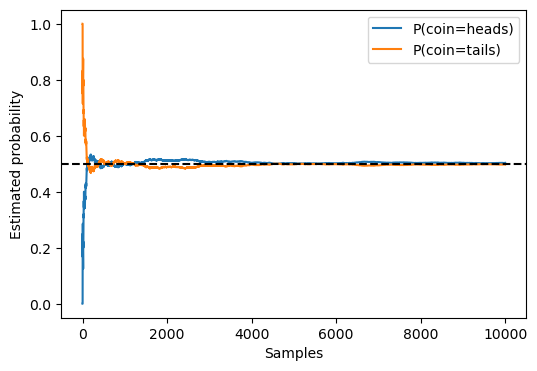

In [69]:
counts = Multinomial(1, fair_probs).sample((10000,))
cum_counts = counts.cumsum(dim=0)
print(counts), print(cum_counts)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
print(cum_counts.sum(dim=1, keepdims=True))
estimates = estimates.numpy()
plt.figure(figsize=(6, 4))
plt.plot(estimates[:, 0], label=("P(coin=heads)"))
plt.plot(estimates[:, 1], label=("P(coin=tails)"))
plt.axhline(y=0.5, color='black', linestyle='dashed')
plt.gca().set_xlabel('Samples')
plt.gca().set_ylabel('Estimated probability')
plt.legend();

In [70]:
print(dir(torch.distributions))

['AbsTransform', 'AffineTransform', 'Bernoulli', 'Beta', 'Binomial', 'CatTransform', 'Categorical', 'Cauchy', 'Chi2', 'ComposeTransform', 'ContinuousBernoulli', 'CorrCholeskyTransform', 'CumulativeDistributionTransform', 'Dirichlet', 'Distribution', 'ExpTransform', 'Exponential', 'ExponentialFamily', 'FisherSnedecor', 'Gamma', 'GeneralizedPareto', 'Geometric', 'Gumbel', 'HalfCauchy', 'HalfNormal', 'Independent', 'IndependentTransform', 'InverseGamma', 'Kumaraswamy', 'LKJCholesky', 'Laplace', 'LogNormal', 'LogisticNormal', 'LowRankMultivariateNormal', 'LowerCholeskyTransform', 'MixtureSameFamily', 'Multinomial', 'MultivariateNormal', 'NegativeBinomial', 'Normal', 'OneHotCategorical', 'OneHotCategoricalStraightThrough', 'Pareto', 'Poisson', 'PositiveDefiniteTransform', 'PowerTransform', 'RelaxedBernoulli', 'RelaxedOneHotCategorical', 'ReshapeTransform', 'SigmoidTransform', 'SoftmaxTransform', 'SoftplusTransform', 'StackTransform', 'StickBreakingTransform', 'StudentT', 'TanhTransform', 'T